In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
tmdb = pd.read_csv('tmdb_5000_movies.csv')

Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv


In [10]:
from google.colab import files
uploaded = files.upload()


import pandas as pd
tmdb = pd.read_csv('rotten_tomatoes_movies.csv')

Saving rotten_tomatoes_movies.csv to rotten_tomatoes_movies.csv


--- TMDB İstatistikleri ---
             budget   popularity  vote_average
count  4.803000e+03  4803.000000   4803.000000
mean   2.904504e+07    21.492301      6.092172
std    4.072239e+07    31.816650      1.194612
min    0.000000e+00     0.000000      0.000000
25%    7.900000e+05     4.668070      5.600000
50%    1.500000e+07    12.921594      6.200000
75%    4.000000e+07    28.313505      6.800000
max    3.800000e+08   875.581305     10.000000


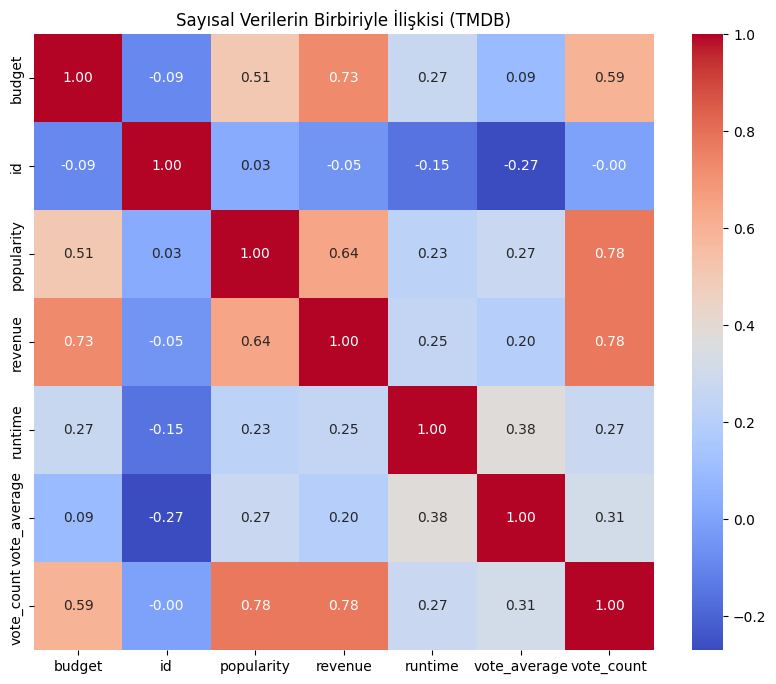


--- HİPOTEZ TESTİ SONUCU ---
Korelasyon Katsayısı: 0.505
P-Değeri: 7.0459e-310
SONUÇ: P-değeri 0.05'ten küçük! Bütçe ve popülerlik arasında istatistiksel olarak anlamlı bir ilişki var. Hipotezimiz DESTEKLENİYOR.


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. VERİLERİ OKUMA
tmdb = pd.read_csv('tmdb_5000_movies.csv')
rt = pd.read_csv('rotten_tomatoes_movies.csv')

# 2. EDA
print("--- TMDB İstatistikleri ---")
print(tmdb[['budget', 'popularity', 'vote_average']].describe())

# 3. GÖRSELLEŞTİRME
plt.figure(figsize=(10, 8))
numeric_tmdb = tmdb.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_tmdb.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sayısal Verilerin Birbiriyle İlişkisi (TMDB)')
plt.show()

# 4. HYPOTHESIS TESTING
# Hipotez:
tmdb_clean = tmdb[['budget', 'popularity']].dropna()
correlation, p_value = stats.pearsonr(tmdb_clean['budget'], tmdb_clean['popularity'])

print("\n--- HİPOTEZ TESTİ SONUCU ---")
print(f"Korelasyon Katsayısı: {correlation:.3f}")
print(f"P-Değeri: {p_value:.4e}")

if p_value < 0.05:
    print("SONUÇ: P-değeri 0.05'ten küçük! Bütçe ve popülerlik arasında istatistiksel olarak anlamlı bir ilişki var. Hipotezimiz DESTEKLENİYOR.")
else:
    print("SONUÇ: Hipotez desteklenmiyor.")